# CS5014 Machine Learning 

### Practical 1


##### Credits: 50% of the coursework

## Aims

The objectives of this assignment are:

* deepen your understanding of linear regression and logistic regression
* gain experience in implementing learning algorithms 
* gain experience in evaluating machine learning algorithms
* gain experience in hyper-parameter tuning


## Set-up

You are **only allowed** to use the following imported packages for this practical. No off-the-shelf machine learning packages such as _scikit-learn_ are allowed. 


In [14]:
# if you use jupyter-lab, switch to %matplotlib inline instead
# %matplotlib inline
%matplotlib inline
%config Completer.use_jedi = False
import matplotlib.pyplot as plt
import autograd.numpy as np  # Thinly-wrapped numpy
from autograd import grad    # The only autograd function you may ever need
import autograd.numpy.linalg as linalg
import matplotlib.pyplot as plt
import pandas as pd

## Question 1 (Logistic regression)

In this question, we are going to implement an logistic regression model to do binary classification on a simulated dataset. The dataset's input feature are four-dimensional vectors $\mathbf{x}^{(i)} \in \mathbb{R}^4$ and as expected the target $y^{(i)} \in \{0, 1\}$. 


The dataset $\{\mathbf{x}^{(i)}, y^{(i)}\}$ is imported below for you:
* ``dataset1``: 2000 observations and each input $\mathbf{x}$ has 4 features 
* and the last column is the target ${y}^{(i)}$
* the dataset is then split into training and testing parts

In [6]:
# read in dataset1
dataset1_df = pd.read_csv('./datasets/dataset1.csv', header=0)
dataset1 = np.array(dataset1_df)
d1X, d1Y = dataset1[:, 0:4], dataset1[:, -1]
# split the data into training and testing 
# the training dataset has the first 1500 observation; 
# in practice, you should randomly shuffle before the split
d1_xtrain, d1_ytrain = d1X[0:1500, :], d1Y[0:1500]
# the testing dataset has the last 500
d1_xtest, d1_ytest = d1X[1500:, :], d1Y[1500:]

As suggested in the lecture, it is convenient to introduce dummy ones to avoid learning the bias separately.

In [7]:
d1_xtrain_dummy = np.column_stack((np.ones(d1_xtrain.shape[0]), d1_xtrain))

### Task 1.1 Implementation of logistic regression

Your task here is to implement a gradient descent based algorithm to train a logistic regression model. For this task, you cannot use `autograd`'s auto-differentiation method (*i.e.* the imported `grad` method). You will be guided to finish the task step by step. 

First, implement the `sigmoid` function:

$$\sigma(z) = \frac{1}{1+e^{-z}}$$

In [8]:
def sigmoid(z):
    # hint: use np.exp(-z)
    sigmoid_output = 1.0 / (1 + np.exp(-z))
    return sigmoid_output

Second, implement the cross-entropy loss and its gradient. You may want to refer to the lecture slides for the details. Recall the binary **C**ross **E**ntropy (CE) _loss_ is 


$$
L(\mathbf{w})=  \frac{1}{n}\sum_{i=1}^n -{y^{(i)}} \ln \sigma^{(i)}- (1- y^{(i)}) \ln (1-\sigma^{(i)})
$$

where $\sigma^{(i)} =\sigma(\mathbf{w}^\top\mathbf{x}^{(i)} + b).$

In [57]:
def cross_entropy_loss(w, X, y):
    #z = w.T @ X
    z = X @ w
    sigmoid_outputs = sigmoid(z)
    mean = np.mean(-(y * np.log(sigmoid_outputs)) - (1-y) * (np.log(1-sigmoid_outputs)))
    return mean

In [53]:
def gradient_ce_loss(w, X, y):
    z = X @ w
    y_hat = sigmoid(z)
    gradient = X.T @ (y - y_hat)
    return -gradient / len(y)

Lastly, implement the gradient descent algorithm.

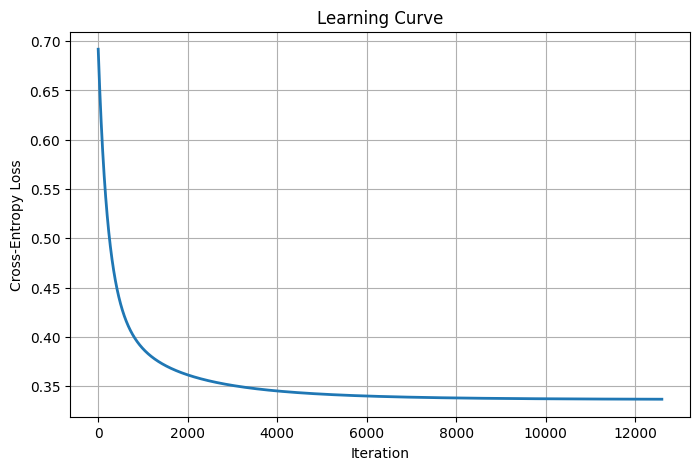

[-2.26761338  1.87998861 -1.00251006  0.39809173 -0.04742812]


In [54]:
def logistic_regression_train(X, y, gamma, tol= 1e-7, maxIters=100000):
    n, d = X.shape 
    # initialise w0
    w0 = np.zeros(d)
    previous_loss = float('inf')
    losses = []
    # loop until converge
    current_iter = 0
    while current_iter < maxIters:
        # Update weights
        w0 = w0 - gamma * gradient_ce_loss(w0, X, y)
        current_loss = cross_entropy_loss(w0, X, y)
        # Converged
        if abs(current_loss - previous_loss) <= tol:
            losses.append(current_loss)
            break

        losses.append(current_loss)
        previous_loss = current_loss
        current_iter += 1

    
    return w0, losses

weights, losses = logistic_regression_train(d1_xtrain_dummy, d1_ytrain, 0.01)
plt.figure(figsize=(8, 5))
plt.plot(losses, linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('Cross-Entropy Loss')
plt.title('Learning Curve')
plt.grid(True)
plt.show()
print(weights)

After you finish implementing all the above methods, use your learning algorithm train a logistic regression model on the training dataset and answer the following questions:

* plot the learning curve
* how did you check whether the learning has converged ?
* report the learning rate parameter used 
* report the learnt parameter $\mathbf{w}$ and bias $b$

### Task 1.2 Testing performance

Implement a prediction method that takes as input the features together with the learnt parameter and output the predicted labels.

In [55]:
def predict_logistic_regression(w, X = d1_xtest):
    n, d = X.shape 
    ## fill the rest of the method
    X = np.column_stack((np.ones(X.shape[0]), X))
    z = X @ w
    sigmoid_values = sigmoid(z)
    classified_values = [1.0 if value >= 0.5 else 0.0 for value in sigmoid_values]
    return classified_values

outputs = predict_logistic_regression(weights)


In [58]:
# Check predictions on test set
outputs = predict_logistic_regression(weights, d1_xtest)
outputs_array = np.array(outputs)

print(f"Predicted as 0: {np.sum(outputs_array == 0)}")
print(f"Predicted as 1: {np.sum(outputs_array == 1)}")

print(f"\nActual 0s in test: {np.sum(d1_ytest == 0)}")
print(f"Actual 1s in test: {np.sum(d1_ytest == 1)}")

# Overall accuracy
overall_acc = np.sum(outputs_array == d1_ytest) / len(d1_ytest)
print(f"\nOverall accuracy: {overall_acc:.2%}")

# Accuracy on class 1 only (your current metric)
class1_acc = accuracy(d1_ytest, outputs)
print(f"Accuracy on class 1: {class1_acc:.2%}")

Predicted as 0: 484
Predicted as 1: 16

Actual 0s in test: 433
Actual 1s in test: 67

Overall accuracy: 86.60%
Accuracy on class 1: 11.94%


Report the test performance on the unseen test dataset.

### Task 1.3 Regularisation

In this sub-task, you are going to apply $L_2$ regularisation to the logistic regression model. The regularised loss is

$$
L(\mathbf{w})=  \frac{1}{n}\sum_{i=1}^n -{y^{(i)}} \ln \sigma^{(i)}- (1- y^{(i)}) \ln (1-\sigma^{(i)}) + \frac{\lambda}{2} \mathbf{w}^\top\mathbf{w}
$$

* where $\lambda >0$ is the regularisation hyperparameter

* note that we do not usually apply penalty on the bias parameter $b$

Implement the following method that fits a regularised logistic regression model with a given $\lambda$.

In [51]:
def logistic_regression_reg_train(X, y, gamma, lam = 1.0, tol= 1e-4, maxIters= 100):
    n, d = X.shape 
    # initialise w0
    w0 = np.zeros(d)
    losses = []
    # loop until converge
    
    return w0

Complete and report the following two results
* report the training loss by setting $\lambda=0.03$
* report the testing performance for the regularised logistic regression model with $\lambda=0.03$

### Task 1.4 Cross-validation

Use K-fold cross-validation (K=5) to choose the optimal $\lambda$. You should use the cross entropy loss as the selection criteria. The candidate hyper-parameter set for $\lambda$ should be 10 numbers between $10^{-3} = 0.001$ and $10^{0}=1$ (*i.e.* 10 numbers in log space). The candidate set is listed below. 

What is the optimal $\lambda$?

In [52]:
lambda_set = np.logspace(-3, 0, 10)
lambda_set

array([0.001     , 0.00215443, 0.00464159, 0.01      , 0.02154435,
       0.04641589, 0.1       , 0.21544347, 0.46415888, 1.        ])

### Task 1.5 Stochastic gradient descent 


Implement a stochastic gradient descent algorithm with mini-batch size of 1. You should consider shuffling the training dataset to improve the convergence speed.

In [53]:
def logistic_regression_reg_sgd_train(X, y, gamma, lam = 1.0, tol= 1e-4, maxIters= 100):
    n, d = X.shape 
    # initialise w0
    w0 = np.zeros(d)
    losses = []
    # loop until converge
        # for each observation (x^i, y^i) in (X, Y)
            # compute gradient and apply gradient descent
    
    return w0

## Question 2 (Fixed basis expansion)



In this question, we are going to implement a fixed basis expansion regression model. The dataset for this question has a univariate feature $\mathbf{x}^{(i)} \in \mathbb{R}$ and as expected the target $y^{(i)} \in \mathbb{R}$ is real valued. 


The dataset is imported below for you:
* ``dataset2``: 1000 observations and each input ${x}^{(i)}$ is a scalar 
* and the last column is the target ${y}^{(i)}$
* the dataset is then split into training and testing parts

In [29]:
# read in dataset2
dataset2_df = pd.read_csv('./datasets/dataset2.csv', header=0)
dataset2 = np.array(dataset2_df)
d2X, d2Y = dataset2[:, 0], dataset2[:, -1]
# split the data into training and testing 
# the training dataset has the first 800 observation; 
# in practice, you should randomly shuffle before the split
d2_xtrain, d2_ytrain = d2X[0:800], d2Y[0:800]
# # the testing dataset has the last 500
d2_xtest, d2_ytest = d2X[800:], d2Y[800:]

The data is plotted below.

In [30]:
plt.scatter(d2_xtrain, d2_ytrain,  c ="blue", s=1.5)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

<IPython.core.display.Javascript object>

### Task 2.1 Basis function

Implement the radian-basis-function (rbf), 

$$\phi(x; \mu, s) = \exp\left \{- \frac{(x-\mu)^2}{2s} \right \}$$

In [31]:
def phi_rbf(x, mu, s):
    return 

### Task 2.2 Fixed basis expansion regression

Implement the fixed basis expansion regression model. Specifically, you should 
* first apply $K$ fixed basis expansion on the input $\{x^{(i)}\}$ to form the expanded design matrix $\mathbf{\Phi}$
* then fit a regression model by a non-iterative algorithm (*i.e.* the normal equation method)

* you are free to choose the $K$ expansion locations, some possible choices
  * select  locations with evenly spaced intervals between $x$'s range 
  * randomly choose  observations from the  training data 
  * randomly select $K$ points within $\{x^{(i)}\}$'s range

In [32]:
def fixed_basis_rbf_reg(X, y, mus, s):
    
    return w

Implement a `predict` method, that output the prediction $\hat{y}$ given input $x_{test}$
* ideally, your method should be able to predict multiple input at the same time (vectorised)

* plot the fitted function on top of the scatter plot of the training data

In [33]:
def predict_rbf_reg(X, w, mus, s):
    return

### Task 2.3 Other basis function


Implement another basis function of your choice and fit the regression model. Plot the fitted result below.

### Task 2.4 Advanced task (extension*)

We assume the noise scale is a constant for ordinary linear regresssion model. However, the noise scale for this dataset increases as $x$ gets larger. This is known as heteroscedasticity. Fit a fixed basis regression model that can also learn the heteroscedasticity. Your are allowed to use auto-differentiation for this question.

## Submission
Hand in via MMS: the completed jupyter notebook. Your notebook should be reproducible.



## Marking
Your submission will be marked as a whole. 

* to get a grade above 7, you are expected to finish at least Task 1.1-1.2 to a good standard
* to get a grade above 10 and up to 13, you are expected to complete Task 1.1-1.4 to a good standard
* to get a grade above 13 and up to 17, you are expected to complete all tasks except 2.3 and 2.4 to a good standard
* to achieve a grade of 17-18, you are expected to finish all tasks except Task 2.4 flawlessly 
* to get 18+, you are expected to attempt all questions flawlessly


Marking is according to the standard mark descriptors published in the Student Handbook at:

https://info.cs.st-andrews.ac.uk/student-handbook/learning-teaching/feedback.html#GeneralMarkDescriptors


You must reference any external sources used. Guidelines for good academic practice are outlined in the student handbook at https://info.cs.st-andrews.ac.uk/student-handbook/academic/gap.html
